# **Getting Started with Images**
lesson to be learnt in this notebook will include the first steps in *Image Processing* and *Computer Vision using OpenCV*. Hence, the following:
- Reading an image
- Check image attributes like datatype and shape
- Matrix representation of an image in Numpy
- Color Images and splitting/merging image channels
- Displaying images using matplotlib
- Saving images

## **Import Libraries**
Install all the neccessary libraries and import them

In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install cv2

Note: you may need to restart the kernel to use updated packages.


In [7]:
# Import the required libraries

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch as th
import time

from PIL import Image
from zipfile import ZipFile
from urllib.request import urlretrieve
from IPython.display import Image, display

%matplotlib inline

In [5]:
# Download the assets
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)


In [ ]:
URL = r"https://www.dropbox.com/s/qhhlqcica1nvtaw/opencv_bootcamp_assets_NB1.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB1.zip")

# Download if assest ZIP does not exists. 
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)  

In [6]:
# Display the 18x18 pixel image

Image(filename="checkerboard_18x18.png")

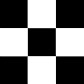

In [4]:
# Display image of 84x84 pixel

Image(filename="checkerboard_84x84.jpg")

### Reading images using OpenCV
OpenCV allows reading different types of images (JPG, PNG, etc). You can load grayscale images, color images or you can also load images with Alpha channel. It uses the **cv2.imread()** function which has the following syntax:
##### Function Syntax
```
retval = cv2.imread( filename[, flags] )
```
retval: Is the image if it is successfully loaded. Otherwise it is None. This may happen if the filename is wrong or the file is corrupt.
The function has 1 required input argument and one optional flag:

```filename```: This can be an absolute or relative path. This is a mandatory argument.
```Flags```: These flags are used to read an image in a particular format (for example, grayscale/color/with alpha channel). This is an optional argument with a default value of cv2.```IMREAD_COLOR``` or 1 which loads the image as a color image.

Before we proceed with some examples, let's also have a look at some of the flags available.

Flags:
- cv2.IMREAD_GRAYSCALE or 0: Loads image in grayscale mode
- cv2.IMREAD_COLOR or 1: Loads a color image. Any transparency of image will be neglected. It is the default flag.
- cv2.IMREAD_UNCHANGED or -1: Loads image as such including alpha channe

In [9]:
cb_img = cv2.imread("checkerboard_18x18.png", 0)

# Print the image data (pixel values), element of a 20 numpy array.
# Each pixel value is 8-bits [0, 255] 
print(cb_img)

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0